In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

from scipy.cluster.hierarchy import dendrogram, linkage

import joblib

c:\Users\deeks\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop("CustomerID", axis=1, inplace=True)

In [8]:
X = df[
    ["Annual Income (k$)",
     "Spending Score (1-100)"]
]

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
linkage_matrix = linkage(
    X_scaled,
    method="ward"
)

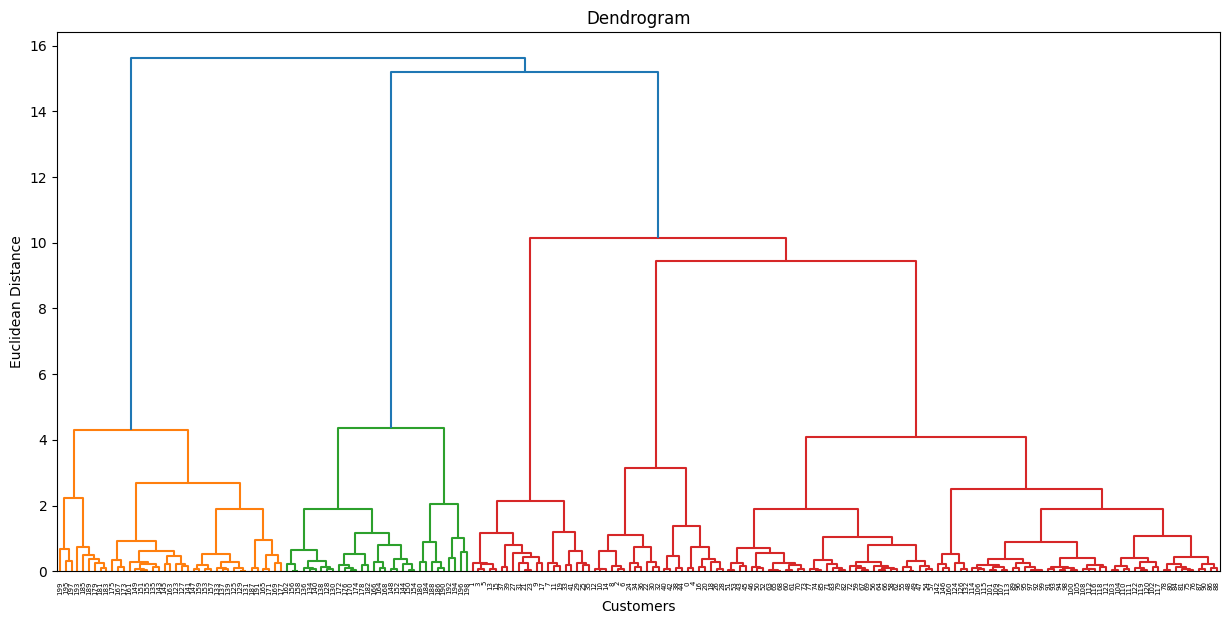

In [11]:
plt.figure(figsize=(15,7))

dendrogram(linkage_matrix)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [12]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

clusters = hc.fit_predict(X_scaled)

In [13]:
df["Cluster"] = clusters

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,4
1,Male,21,15,81,3
2,Female,20,16,6,4
3,Female,23,16,77,3
4,Female,31,17,40,4


In [24]:
import joblib

joblib.dump(
    df,
    "models/hierarchical_clustered_df.pkl"
)

['models/hierarchical_clustered_df.pkl']

In [14]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.5538089226688662


In [15]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(
    X_scaled,
    clusters
)

print("Davies-Bouldin Score:", db_score)

Davies-Bouldin Score: 0.5778621190740154


In [16]:
df["Cluster"].value_counts().sort_index()

Cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64

In [17]:
cluster_summary = df.groupby("Cluster")[
    ["Annual Income (k$)",
     "Spending Score (1-100)"]
].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,89.406250,15.593750
1,86.538462,82.128205
2,55.811765,49.129412
3,25.095238,80.047619
4,26.304348,20.913043


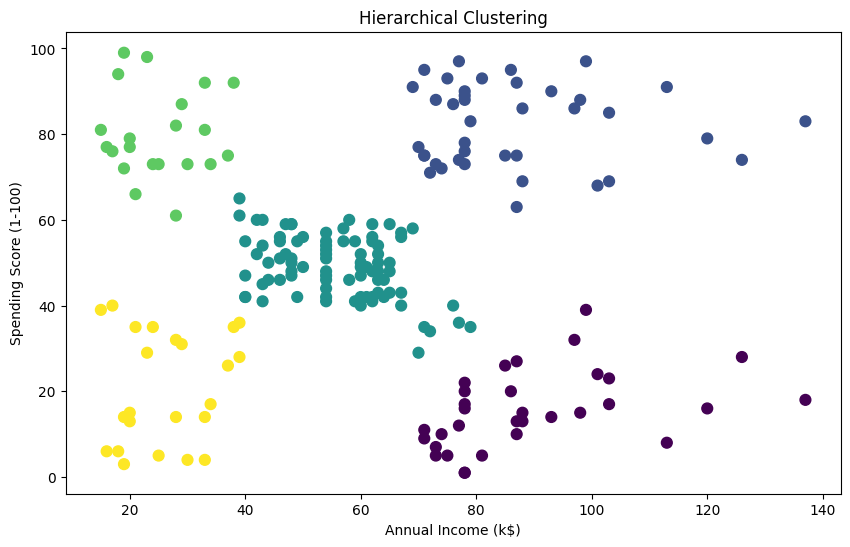

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hierarchical Clustering")

plt.show()


In [19]:
cluster_centers = df.groupby("Cluster")[
    ["Annual Income (k$)",
     "Spending Score (1-100)"]
].mean()

cluster_centers

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,89.406250,15.593750
1,86.538462,82.128205
2,55.811765,49.129412
3,25.095238,80.047619
4,26.304348,20.913043


In [21]:
import joblib

joblib.dump(
    cluster_centers,
    "models/cluster_centers.pkl"
)



['models/cluster_centers.pkl']

In [22]:
joblib.dump(
    scaler,
    "models/scaler.pkl"
)

['models/scaler.pkl']